<a href="https://colab.research.google.com/github/ramyanagavelli463-maker/N.Ramya/blob/main/Predictive_Analytics_Historical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance statsmodels scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [3]:
data = yf.download(
    'AAPL',
    start='2018-01-01',
    end='2023-12-31'
)

data.head()


/tmp/ipykernel_2844/489635175.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.232380,40.241724,39.531711,39.741914,102223600
2018-01-03,40.225361,40.767213,40.162303,40.295428,118071600
2018-01-04,40.412220,40.514985,40.190342,40.297776,89738400
2018-01-05,40.872318,40.958733,40.416885,40.507971,94640000
2018-01-08,40.720512,41.014792,40.622416,40.720512,82271200


In [4]:
data = data[['Close']]

data.head()

Price,Close
Ticker,AAPL
Date,
2018-01-02,40.232380
2018-01-03,40.225361
2018-01-04,40.412220
2018-01-05,40.872318
2018-01-08,40.720512


In [5]:
print(data.shape)
print(data.isnull().sum())
print(data.describe())


(1509, 1)
Price  Ticker
Close  AAPL      0
dtype: int64
Price         Close
Ticker         AAPL
count   1509.000000
mean     107.531711
std       50.795831
min       33.707920
25%       51.098339
50%      120.137726
75%      149.813004
max      195.723816


In [6]:
data = data.dropna()

print(data.isnull().sum())

Price  Ticker
Close  AAPL      0
dtype: int64


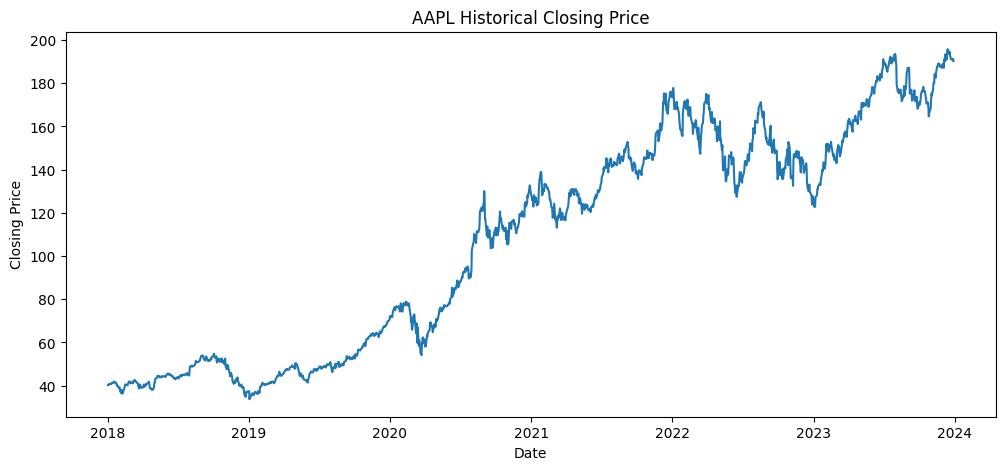

In [7]:
plt.figure(figsize=(12,5))

plt.plot(data['Close'])

plt.title('AAPL Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [8]:
train_size = int(len(data) * 0.8)

train = data['Close'][:train_size]
test = data['Close'][train_size:]

print("Training data:", len(train))
print("Testing data:", len(test))


Training data: 1207
Testing data: 302


In [9]:
model = ARIMA(train, order=(5,1,2))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/p

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1207
Model:                 ARIMA(5, 1, 2)   Log Likelihood               -2584.416
Date:                Fri, 18 Sep 2026   AIC                           5184.831
Time:                        13:19:57   BIC                           5225.592
Sample:                             0   HQIC                          5200.181
                               - 1207                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.8626      0.036    -51.068      0.000      -1.934      -1.791
ar.L2         -1.0378      0.055    -18.719      0.000      -1.147      -0.929
ar.L3         -0.1169      0.049     -2.371      0.0

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [12]:
# Select Close price
close_data = data['Close']

# If Close is a DataFrame, convert it to a Series
if isinstance(close_data, pd.DataFrame):
    close_data = close_data.iloc[:, 0]

# Remove missing values
close_data = close_data.dropna()

# Make sure the index is a proper date index
close_data.index = pd.to_datetime(close_data.index)

print(close_data.head())
print(close_data.shape)

Date
2018-01-02    40.232380
2018-01-03    40.225361
2018-01-04    40.412220
2018-01-05    40.872318
2018-01-08    40.720512
Name: AAPL, dtype: float64
(1509,)


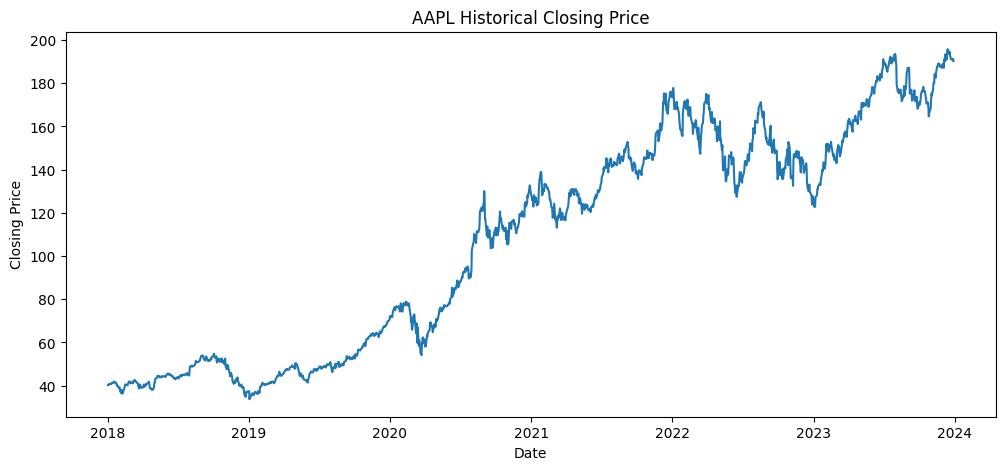

In [13]:
plt.figure(figsize=(12,5))

plt.plot(close_data)

plt.title('AAPL Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

In [14]:
train_size = int(len(close_data) * 0.8)

train = close_data.iloc[:train_size]
test = close_data.iloc[train_size:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 1207
Testing data: 302


In [30]:
# Create a simpler ARIMA model
model = ARIMA(train, order=(1, 1, 1))

model_fit = model.fit()

print("ARIMA model fitted successfully!")

ARIMA model fitted successfully!


In [31]:
forecast = model_fit.forecast(steps=len(test))

print("Forecast created successfully!")
print(forecast[:10])

Forecast created successfully!
1207    139.494100
1208    139.443920
1209    139.430443
1210    139.426823
1211    139.425851
1212    139.425590
1213    139.425520
1214    139.425501
1215    139.425496
1216    139.425495
Name: predicted_mean, dtype: float64


In [32]:
comparison = pd.DataFrame({
    'Actual': test.to_numpy(),
    'Predicted': forecast.to_numpy()
})

print(comparison.head(10))

       Actual   Predicted
0  140.995270  139.494100
1  141.103165  139.443920
2  140.642181  139.430443
3  144.447815  139.426823
4  146.586044  139.425851
5  149.420670  139.425590
6  146.487976  139.425520
7  142.025146  139.425501
8  152.755478  139.425496
9  150.401474  139.425495


In [33]:
mae = mean_absolute_error(
    test.to_numpy(),
    forecast.to_numpy()
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 27.25828881970821


In [34]:
rmse = np.sqrt(
    mean_squared_error(
        test.to_numpy(),
        forecast.to_numpy()
    )
)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 32.117287094825336


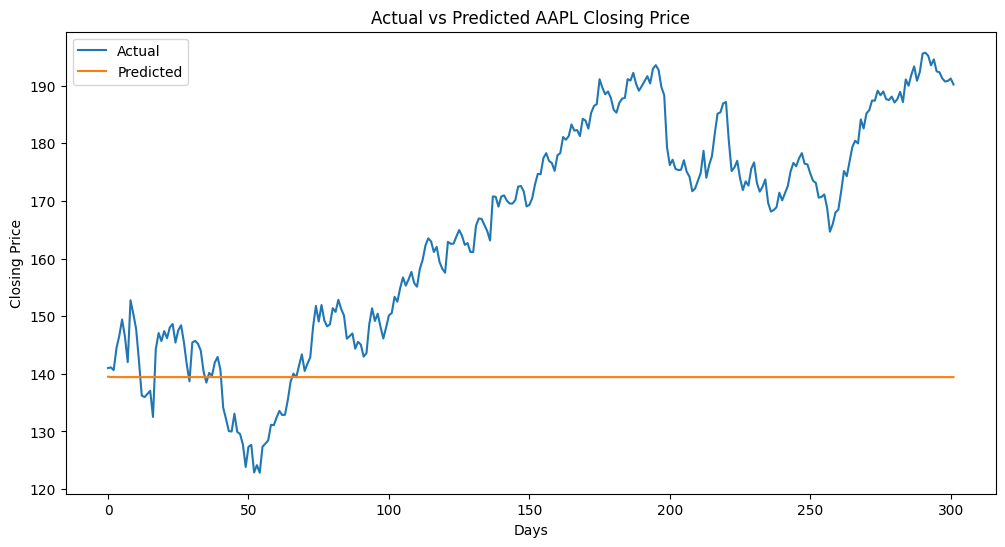

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(test.to_numpy(), label='Actual')
plt.plot(forecast.to_numpy(), label='Predicted')

plt.title('Actual vs Predicted AAPL Closing Price')
plt.xlabel('Days')
plt.ylabel('Closing Price')

plt.legend()
plt.show()

In [36]:
# Train final model using all historical data
final_model = ARIMA(close_data, order=(1, 1, 1))

final_model_fit = final_model.fit()

# Forecast next 30 days
future_forecast = final_model_fit.forecast(steps=30)

print("Next 30 days forecast:")
print(future_forecast)

Next 30 days forecast:
1509    190.248833
1510    190.263595
1511    190.269359
1512    190.271610
1513    190.272489
1514    190.272832
1515    190.272966
1516    190.273018
1517    190.273039
1518    190.273047
1519    190.273050
1520    190.273051
1521    190.273052
1522    190.273052
1523    190.273052
1524    190.273052
1525    190.273052
1526    190.273052
1527    190.273052
1528    190.273052
1529    190.273052
1530    190.273052
1531    190.273052
1532    190.273052
1533    190.273052
1534    190.273052
1535    190.273052
1536    190.273052
1537    190.273052
1538    190.273052
Name: predicted_mean, dtype: float64


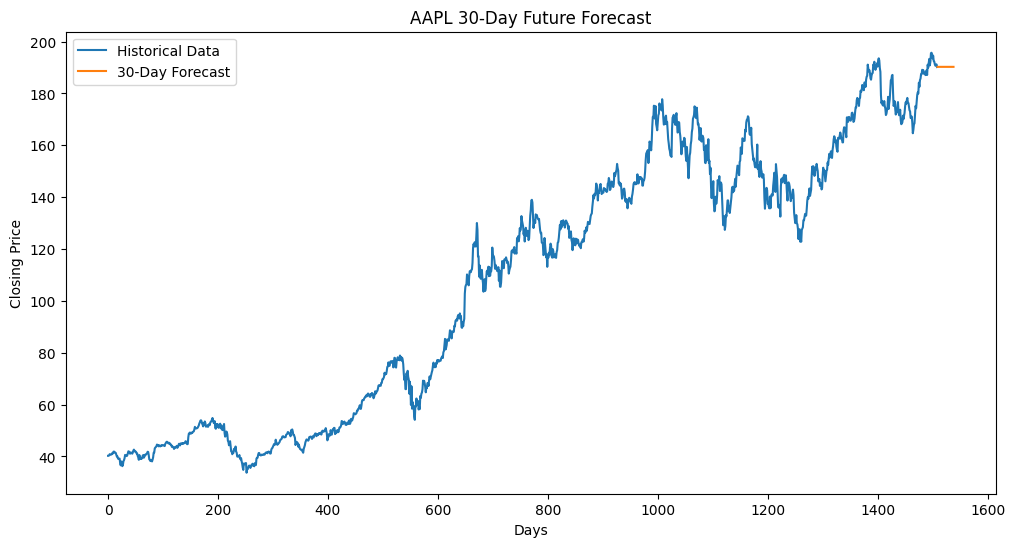

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(close_data, label='Historical Data')

future_index = range(
    len(close_data),
    len(close_data) + 30
)

plt.plot(
    future_index,
    future_forecast.to_numpy(),
    label='30-Day Forecast'
)

plt.title('AAPL 30-Day Future Forecast')
plt.xlabel('Days')
plt.ylabel('Closing Price')

plt.legend()
plt.show()

In [38]:
future_forecast_df = pd.DataFrame({
    'Day': range(1, 31),
    'Predicted_Close_Price': future_forecast.to_numpy()
})

future_forecast_df.to_csv(
    'AAPL_30_Day_Forecast.csv',
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!


In [40]:
print("MAE:", mae)
print("RMSE:", rmse)

print("\n30-Day Forecast:")
print(future_forecast_df)

MAE: 27.25828881970821
RMSE: 32.117287094825336

30-Day Forecast:
    Day  Predicted_Close_Price
0     1             190.248833
1     2             190.263595
2     3             190.269359
3     4             190.271610
4     5             190.272489
5     6             190.272832
6     7             190.272966
7     8             190.273018
8     9             190.273039
9    10             190.273047
10   11             190.273050
11   12             190.273051
12   13             190.273052
13   14             190.273052
14   15             190.273052
15   16             190.273052
16   17             190.273052
17   18             190.273052
18   19             190.273052
19   20             190.273052
20   21             190.273052
21   22             190.273052
22   23             190.273052
23   24             190.273052
24   25             190.273052
25   26             190.273052
26   27             190.273052
27   28             190.273052
28   29             190.273052
29  

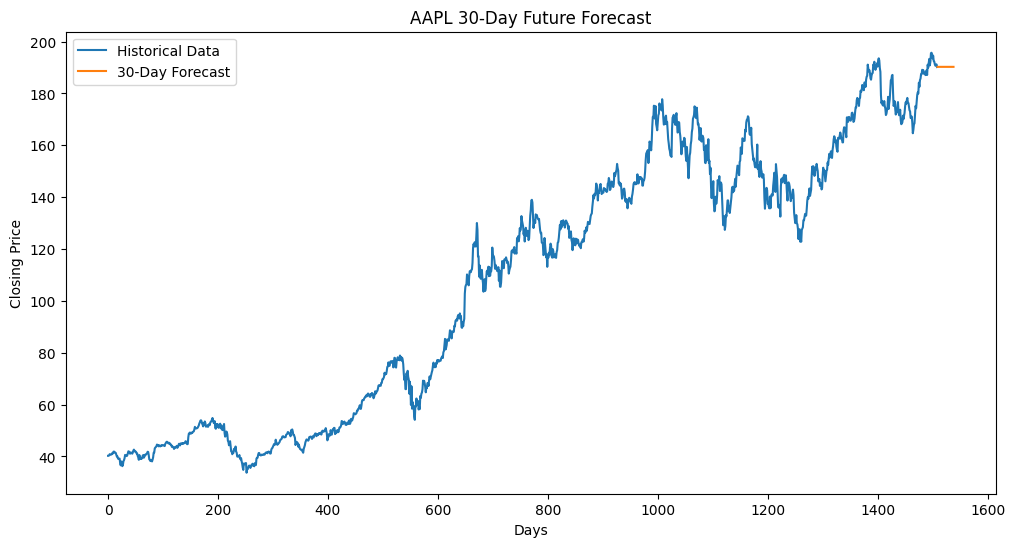

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(close_data, label='Historical Data')

future_index = range(
    len(close_data),
    len(close_data) + 30
)

plt.plot(
    future_index,
    future_forecast.to_numpy(),
    label='30-Day Forecast'
)

plt.title('AAPL 30-Day Future Forecast')
plt.xlabel('Days')
plt.ylabel('Closing Price')

plt.legend()
plt.show()